In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
#import plotly.express as px 
import seaborn as sns

In [2]:
dsf_data = pd.read_csv("data/2025-08-15_FlA_ZP_CKW_20250815_145006_AnalysisResults_wellresults_edited.txt", sep="\t")

pd.set_option('display.max_columns', None)

In [3]:
plotdata = pd.melt(dsf_data, id_vars=["Protein", "Ligand"], value_vars=["Tm B"])
plotdata = plotdata.groupby(by=["Protein", "Ligand"])["value"].agg(["mean", "std"]).reset_index()

In [4]:
lig_dict = {
    'C2': 'Storage Buffer',
    'SAM': 'Storage Buffer + SAM',
    'rxn': 'Reaction Buffer + F-'
}

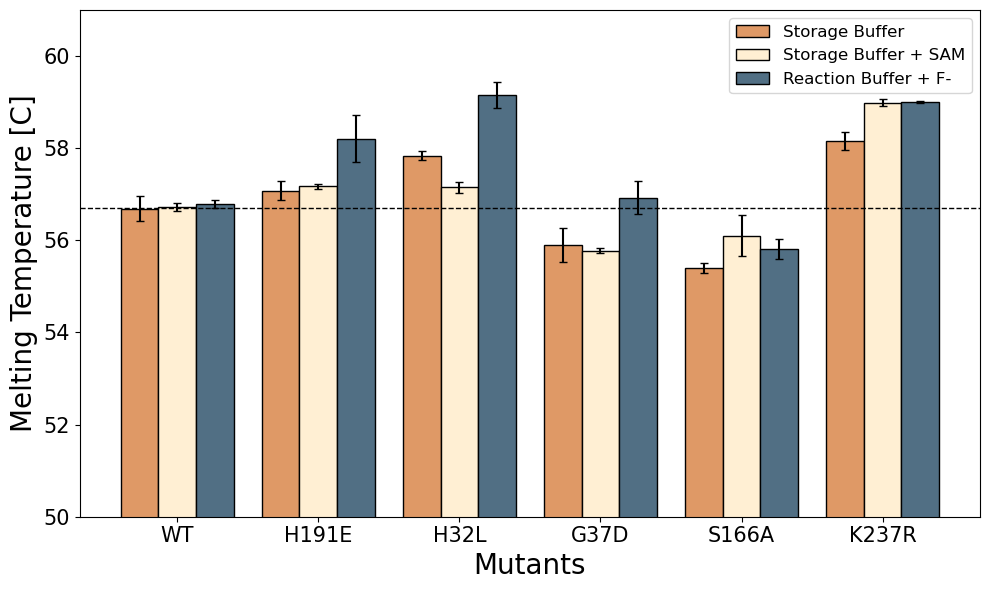

In [23]:
# Order proteins
protein_order = ["FlA_WT", "FlA_H191E", "FlA_H32L", "FlA_G37D", "FlA_S166A", "FlA_K237R"]
plotdata["Protein"] = pd.Categorical(plotdata["Protein"], categories=protein_order, ordered=True)
plotdata = plotdata.sort_values(["Protein", "Ligand"])

# Order ligands
ligand_order = list(plotdata["Ligand"].drop_duplicates())

color_map = dict(zip(ligand_order, ["#DF9966", '#FFEFD3', "#516F84"][:len(ligand_order)]))

# Pivot for consistent alignment (rows: proteins, cols: ligands)
mean_piv = plotdata.pivot(index="Protein", columns="Ligand", values="mean").reindex(protein_order)
std_piv  = plotdata.pivot(index="Protein", columns="Ligand", values="std").reindex(protein_order)

# X positions and grouped bar offsets
x = np.arange(len(protein_order))
nL = len(ligand_order)
total_width = 0.8
bar_w = total_width / max(nL, 1)
offsets = (np.arange(nL) - (nL - 1) / 2.0) * bar_w

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for i, lig in enumerate(ligand_order):
    y    = mean_piv[lig].to_numpy()
    yerr = std_piv[lig].to_numpy()
    # Handle missing combos gracefully
    y_plot    = np.nan_to_num(y, nan=0.0)
    yerr_plot = np.nan_to_num(yerr, nan=0.0)

    ax.bar(
        x + offsets[i],
        y_plot,
        width=bar_w,
        yerr=yerr_plot,
        label=lig_dict.get(lig, lig),
        edgecolor="black",
        linewidth=1.0,
        capsize=3,
        color=color_map.get(lig, None),
    )

# Reference line and limits
ax.axhline(56.7, linestyle="--", linewidth=1.0, color="black")
ax.set_ylim(50, 60)

# Labels, ticks, legend
ax.set_xlabel("Mutants",fontsize=20)
ax.set_ylabel("Melting Temperature [C]",fontsize=20)
ax.set_xticks(x)
ax.set_xticklabels(["WT", "H191E", "H32L", "G37D", "S166A", "K237R"], rotation=0, ha="center")
ax.legend(fontsize=12)

ax.set_ylim(50,61)

ax.tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.show()



In [16]:
plotdata[plotdata.Protein=='FlA_K237R']['mean'].values - plotdata[plotdata.Protein=='FlA_WT']['mean'].values

array([1.47450967, 2.25744133, 2.20944833])

In [17]:
plotdata[plotdata.Protein=='FlA_H191E']['mean'].values - plotdata[plotdata.Protein=='FlA_WT']['mean'].values

array([0.396134  , 0.44715467, 1.41929333])

In [20]:
plotdata[plotdata.Protein=='FlA_H32L']['mean'].values - plotdata[plotdata.Protein=='FlA_WT']['mean'].values

array([1.15566233, 0.42251033, 2.36267933])

In [18]:
plotdata[plotdata.Protein=='FlA_H191E']['mean'].values 

array([57.08099067, 57.175448  , 58.20866533])

In [21]:
plotdata[plotdata.Protein=='FlA_WT']['mean'].values

array([56.68485667, 56.72829333, 56.789372  ])

In [22]:
plotdata[plotdata.Protein=='FlA_K237R']['mean'].values

array([58.15936633, 58.98573467, 58.99882033])